In [33]:
! pip install pandas numpy
! pip install --upgrade pip

In [34]:
import pandas as pd
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [35]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [36]:
X = df.drop(
    'Class',
    axis=1
)

y = df['Class']

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
y_train.value_counts()

Class
0    227451
1       394
Name: count, dtype: int64

In [39]:
! pip install imbalanced-learn

In [40]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [41]:
y_train_smote.value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_smote
)

X_test_scaled = scaler.transform(
    X_test
)

In [43]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(
    random_state=42
)

In [44]:
dt_model.fit(
    X_train_scaled,
    y_train_smote
)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [45]:
y_pred_dt = dt_model.predict(
    X_test_scaled
)

In [46]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)

print(
    classification_report(
        y_test,
        y_pred_dt
    )
)

print(
    roc_auc_score(
        y_test,
        y_pred_dt
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.42      0.80      0.55        98

    accuracy                           1.00     56962
   macro avg       0.71      0.90      0.78     56962
weighted avg       1.00      1.00      1.00     56962

0.897027135277296


In [47]:
roc_auc_dt = roc_auc_score(
    y_test,
    y_pred_dt
)

print(roc_auc_dt)

0.897027135277296


In [48]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [49]:
rf_model.fit(
    X_train_scaled,
    y_train_smote
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [50]:
y_pred_rf = rf_model.predict(
    X_test_scaled
)

In [51]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

print(
    roc_auc_score(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

0.9131158266626853


In [52]:
roc_auc_rf = roc_auc_score(
    y_test,
    y_pred_rf
)

print(roc_auc_rf)

0.9131158266626853


In [53]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    learning_rate=0.1,
    max_depth=5,
    n_estimators=100,
    random_state=42
)

In [54]:
xgb_model.fit(
    X_train_scaled,
    y_train_smote
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [55]:
y_pred_xgb = xgb_model.predict(
    X_test_scaled
)

In [56]:
y_prob_xgb = xgb_model.predict_proba(
    X_test_scaled
)[:,1]

In [57]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)

print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

print(
    roc_auc_score(
        y_test,
        y_prob_xgb
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.36      0.88      0.51        98

    accuracy                           1.00     56962
   macro avg       0.68      0.94      0.75     56962
weighted avg       1.00      1.00      1.00     56962

0.9785735639922823


In [58]:
roc_auc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

print(roc_auc_xgb)

0.9785735639922823


In [59]:
comparison = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],
    'ROC_AUC': [
        roc_auc_dt,
        roc_auc_rf,
        roc_auc_xgb
    ]
})

comparison

,Model,ROC_AUC
0,Decision Tree,0.897027
1,Random Forest,0.913116
2,XGBoost,0.978574


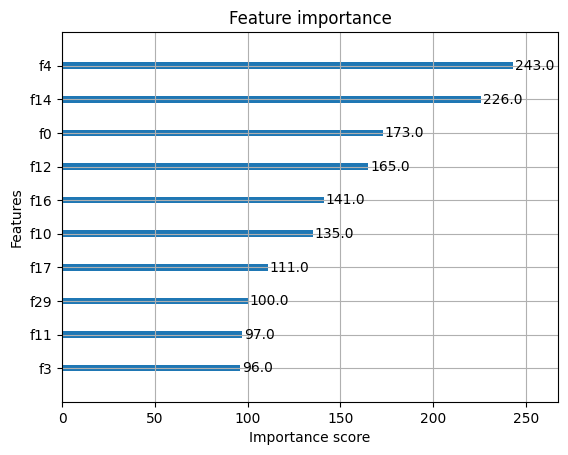

In [60]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(
    xgb_model,
    max_num_features=10
)

plt.show()

In [61]:
! pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 1.4 MB/s  0:00:0036m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 11.0 MB/s  0:00:03eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 26.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [shap]4/5 [shap]]te]


/Users/ashna/.pyenv/versions/3.13.5/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


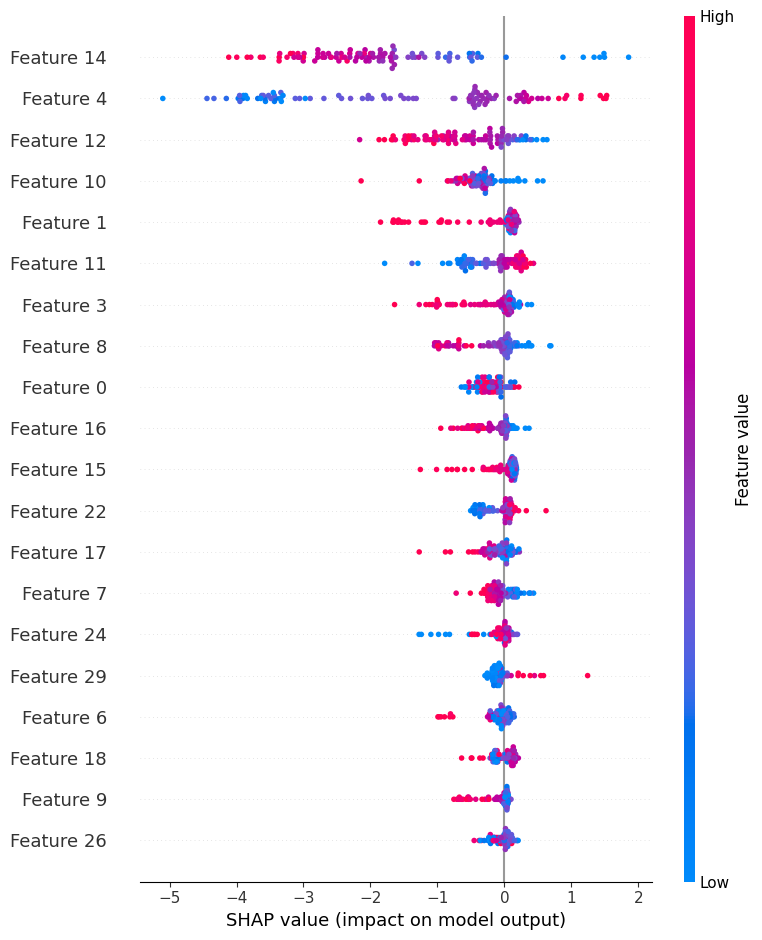

In [62]:
import shap

explainer = shap.TreeExplainer(
    xgb_model
)

X_sample = X_test_scaled[:100]

shap_values = explainer.shap_values(
    X_sample
)

shap.summary_plot(
    shap_values,
    X_sample
)